In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Load dataset

In [ ]:
def load_dataset(dataset_path, batch_size=32, test_split=0.2):

    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # center crop
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    full_dataset = torchvision.datasets.ImageFolder(dataset_path, transform=train_transform)
    train_size = int((1 - test_split) * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    test_dataset.dataset = torchvision.datasets.ImageFolder(dataset_path, transform=test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    num_classes = len(full_dataset.classes)
    class_names = full_dataset.classes
    
    print(f"Dataset caricato:")
    print(f"- Numero di classi: {num_classes}")
    print(f"- Classi: {class_names}")
    print(f"- Training samples: {len(train_dataset)}")
    print(f"- Test samples: {len(test_dataset)}")
    
    return train_loader, test_loader, num_classes, class_names

## Model

In [ ]:
class FineTunedAlexNet(nn.Module):
    def __init__(self, num_classes):
        super(FineTunedAlexNet, self).__init__()
        self.alexnet = torchvision.models.alexnet(weights=True)
        
        # Congela i layer convoluzionali per il fine-tuning
        for param in self.alexnet.features.parameters():
            param.requires_grad = False
        
        # Modifica il classificatore finale
        self.alexnet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(9216, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    
    def forward(self, x):
        return self.alexnet(x)

class ASAPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, operation='conv3x3'):
        super(ASAPBlock, self).__init__()
        self.operation = operation
        
        if operation == 'conv3x3':
            self.op = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        elif operation == 'conv5x5':
            self.op = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 5, padding=2),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        elif operation == 'depthwise':
            self.op = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels),
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        elif operation == 'maxpool':
            self.op = nn.Sequential(
                nn.MaxPool2d(3, stride=1, padding=1),
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
    
    def forward(self, x):
        return self.op(x)

class ASAPNetwork(nn.Module):
    def __init__(self, num_classes):
        super(ASAPNetwork, self).__init__()
        
        self.features = nn.Sequential(
            
            # Stage 1
            ASAPBlock(3, 32, 'conv3x3'),
            nn.MaxPool2d(2),
            
            # Stage 2
            ASAPBlock(32, 64, 'depthwise'),
            ASAPBlock(64, 64, 'conv3x3'),
            nn.MaxPool2d(2),
            
            # Stage 3
            ASAPBlock(64, 128, 'conv5x5'),
            ASAPBlock(128, 128, 'depthwise'),
            nn.MaxPool2d(2),
            
            # Stage 4
            ASAPBlock(128, 256, 'conv3x3'),
            ASAPBlock(256, 256, 'maxpool'),
            nn.MaxPool2d(2),
            
            # Stage 5
            ASAPBlock(256, 512, 'depthwise'),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

class XNASCell(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(XNASCell, self).__init__()
        
        self.ops = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels, bias=False),
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ),

            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ),

            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels)
            ) if in_channels != out_channels else nn.Identity()
        ])
        
        self.alpha = nn.Parameter(torch.ones(len(self.ops)))
    
    def forward(self, x):
        weights = torch.softmax(self.alpha, dim=0)
        out = sum(w * op(x) for w, op in zip(weights, self.ops))
        return out

class XNASNetwork(nn.Module):
    def __init__(self, num_classes):
        super(XNASNetwork, self).__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.cells = nn.ModuleList([
            XNASCell(32, 64),
            XNASCell(64, 128),
            nn.MaxPool2d(2),
            XNASCell(128, 256),
            nn.MaxPool2d(2),
            XNASCell(256, 512),
            nn.AdaptiveAvgPool2d((2, 2))
        ])
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512 * 4, num_classes)
        )
    
    def forward(self, x):
        x = self.stem(x)
        for cell in self.cells:
            x = cell(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

class VisionTransformer(nn.Module):
    def __init__(self, num_classes):
        super(VisionTransformer, self).__init__()
        try:
            self.backbone = torchvision.models.vit_b_16(weights=True)
            self.backbone.heads = nn.Linear(768, num_classes)
            
        except:
            self.backbone = torchvision.models.resnet34(weights=True)
            self.backbone.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

## Train

In [ ]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, method_name="Model"):
    print(f"\n=== Training {method_name} ===")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    train_losses = []
    train_accs = []
    test_accs = []
    
    best_acc = 0.0
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += target.size(0)
            correct_train += predicted.eq(target).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        train_acc = 100. * correct_train / total_train
        train_loss = running_loss / len(train_loader)
        test_acc = test_model(model, test_loader, verbose=False)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), f'best_{method_name.lower().replace(" ", "_")}_model.pth')
        
        scheduler.step()
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f"Training completato in {training_time:.2f} secondi")
    print(f"Migliore accuratezza: {best_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'best_acc': best_acc,
        'training_time': training_time,
        'final_error': 100 - best_acc
    }

## Test

In [ ]:
def test_model(model, test_loader, verbose=True):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = 100. * correct / total
    
    if verbose:
        print(f'Test Accuracy: {accuracy:.2f}%')
        print(f'Test Error: {100 - accuracy:.2f}%')
    
    return accuracy

## Plot

In [ ]:
def plot_training_curves(results_dict, class_names):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Training Loss
    ax = axes[0, 0]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['train_losses']) + 1)
        ax.plot(epochs, results['train_losses'], label=method_name, linewidth=2)
        
    ax.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Training Accuracy
    ax = axes[0, 1]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['train_accs']) + 1)
        ax.plot(epochs, results['train_accs'], label=method_name, linewidth=2)
    ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Accuracy
    ax = axes[1, 0]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['test_accs']) + 1)
        ax.plot(epochs, results['test_accs'], label=method_name, linewidth=2)
    ax.set_title('Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Comparison Bar Chart
    ax = axes[1, 1]
    methods = list(results_dict.keys())
    best_accs = [results_dict[method]['best_acc'] for method in methods]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    bars = ax.bar(methods, best_accs, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title('Best Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    
    # Aggiungi valori sulle barre
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_results_table(results_dict):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')
    table_data = []
    headers = ['Method', 'Best Accuracy (%)', 'Final Error (%)', 'Training Time (s)', 'Parameters']
    
    for method_name, results in results_dict.items():
        row = [
            method_name,
            f"{results['best_acc']:.1f}%",
            f"{results['final_error']:.1f}%",
            f"{results['training_time']:.0f}s",
            "N/A"
        ]
        table_data.append(row)
    
    table = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2)
    
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#F5F5F5')
    
    plt.title('Results Summary', fontsize=16, fontweight='bold', pad=20)
    plt.show()

ESPERIMENTO DI CLASSIFICAZIONE CON 4 METODI
Caricamento dataset...
Dataset caricato:
- Numero di classi: 25
- Classi: ['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']
- Training samples: 3957
- Test samples: 990


c:\Users\Testing\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Testing\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



METODO: Vision Transformer

=== Training Vision Transformer ===


Epoch 1/100: 100%|██████████| 124/124 [01:18<00:00,  1.58it/s, Loss=3.2824, Acc=6.85%]


Epoch 1: Train Loss: 3.2824, Train Acc: 6.85%, Test Acc: 6.77%


...

Epoch 98: Train Loss: 0.1729, Train Acc: 95.02%, Test Acc: 85.15%


Epoch 99/100: 100%|██████████| 124/124 [01:11<00:00,  1.73it/s, Loss=0.1449, Acc=95.86%]


Epoch 99: Train Loss: 0.1449, Train Acc: 95.86%, Test Acc: 85.15%


Epoch 100/100: 100%|██████████| 124/124 [01:07<00:00,  1.83it/s, Loss=0.1605, Acc=95.30%]


Epoch 100: Train Loss: 0.1605, Train Acc: 95.30%, Test Acc: 85.15%
Training completato in 8008.53 secondi
Migliore accuratezza: 86.46%

RISULTATI FINALI

Vision Transformer:
  - Migliore Accuratezza: 86.5%
  - Errore Finale: 13.5%
  - Tempo di Training: 8009s

Generazione grafici...


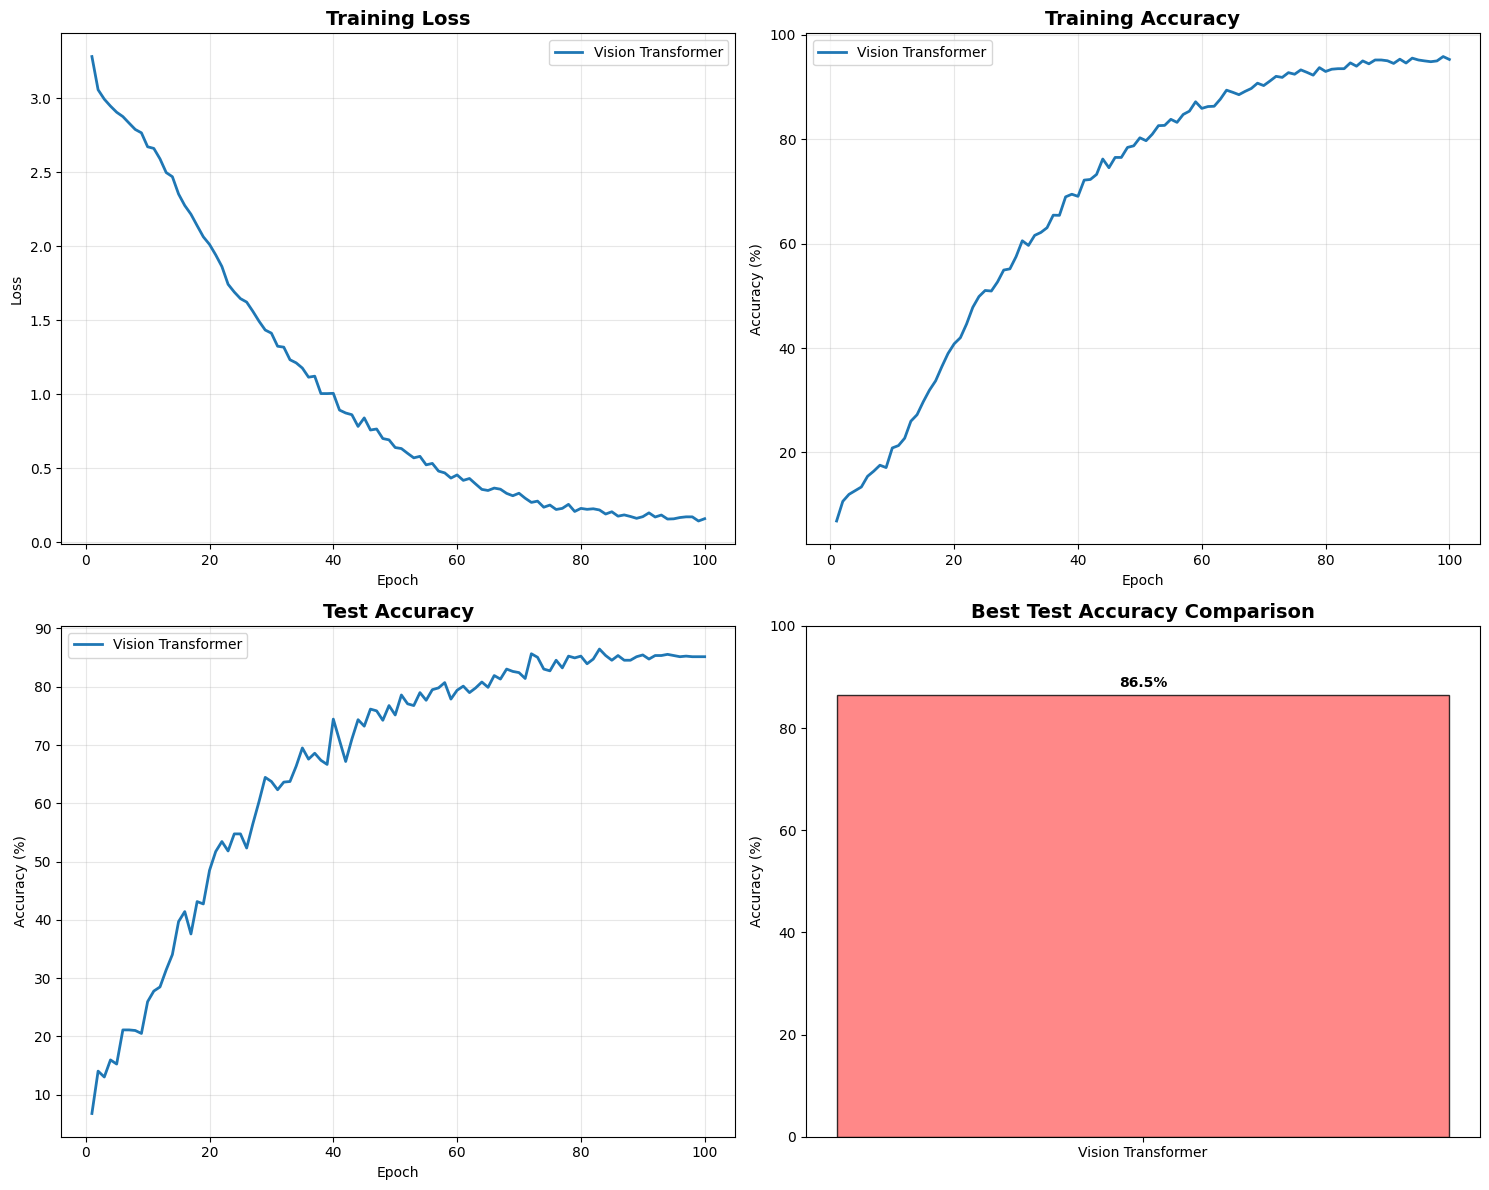

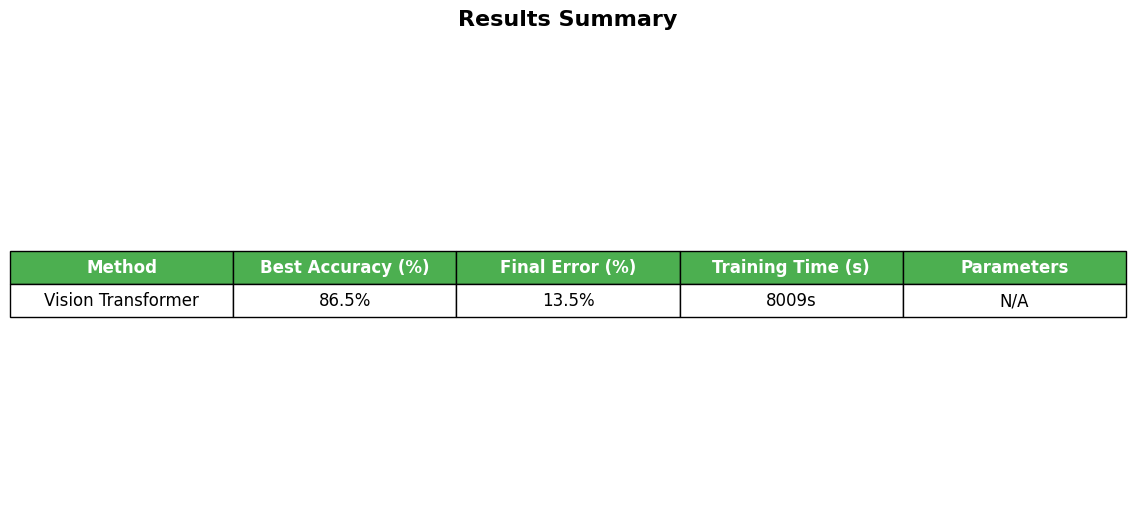


Esperimento completato!
I modelli migliori sono stati salvati come 'best_*_model.pth'


In [ ]:
def main():
    dataset_path = "dataset"
    
    train_loader, test_loader, num_classes, class_names = load_dataset(
        dataset_path, batch_size=32, test_split=0.2 
    )
    
    models = {
        #'Fine-tuned AlexNet': FineTunedAlexNet(num_classes).to(device),
        #'ASAP': ASAPNetwork(num_classes).to(device),
        #'XNAS': XNASNetwork(num_classes).to(device),
        'Vision Transformer': VisionTransformer(num_classes).to(device)
    }
    
    results_dict = {}
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    for method_name, model in models.items():
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"\n{'='*60}")
        print(f"METODO: {method_name}")
        print('='*60)
        
        results = train_model(
            model, train_loader, test_loader, 
            epochs=80,
            lr=0.01,
            method_name=method_name
        )
        
        results_dict[method_name] = results
    
    print("\n" + "="*80)
    print("RISULTATI FINALI")
    print("="*80)
    
    for method_name, results in results_dict.items():
        print(f"\n{method_name}:")
        print(f"  - Migliore Accuratezza: {results['best_acc']:.1f}%")
        print(f"  - Errore Finale: {results['final_error']:.1f}%")
        print(f"  - Tempo di Training: {results['training_time']:.0f}s")
    
    print("\nGenerazione grafici...")
    plot_training_curves(results_dict, class_names)
    plot_results_table(results_dict)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
main()